In [1]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from sphWarpCore.math import *
from sphWarpCore.util import castTorchToWarp, castWarpToTorch, castTorchToWarpAsBuiltins
from sphWarpCore.radiusSearch.wp_radius_small import warp_radius_search_small
from sphWarpCore.radius import *
from warp.types import vector
from sphWarpCore.autograd import warpWrapper, WarpFunctionWrapper
from sphWarpCore.ops import *

wp.config.verify_autograd_array_access = True
wp.config.verbose = True


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/winchenbach/.cache/warp/1.12.0


In [2]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [3]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

# hashMapLength = getNextPrime(numParticles)
# periodic = False
# x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

# pointCloud = PointCloud(x, h)
# queryPositions = pointCloud.positions
# querySupports = pointCloud.supports
# referencePositions = pointCloud.positions
# referenceSupports = pointCloud.supports
# mode = 'gather'

# offset = 0

In [4]:
from sphWarpCore.ops import computeSPHInterpolant_warpBackend, computeDensity_warpBackend
from sphWarpCore.enumTypes import *
import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *
from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme, computeNeighborhoodStates


In [5]:
from sphWarpCore.enumTypes import GradientScheme
from sphWarpCore.operations.wp_gradient_scalar import computeSPHGradientScalar_warpBackend

In [6]:
from diffSPH.enums import Operation, SupportScheme, GradientMode
from diffSPH.operations import SPHOperation


In [7]:
from sphWarpCore.operations.wp_gradient_vector import computeSPHGradientVector_warpBackend

In [8]:
from sphWarpCore.operations.wp_gradient_matrix import computeSPHGradientMatrix_warpBackend

In [9]:
from sphWarpCore.operations.wp_gradient import computeSPHGradient_warpBackend

In [10]:
from sphWarpCore.radiusSearch.wp_compactHash import radiusSearchCompactHashMap
def runWarpCompact(
    queryPositions, querySupports, referencePositions, referenceSupports, domain, mode, hashMapLength
):
    return radiusSearchCompactHashMap(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        periodicity = domain.periodic, domainDescription=domain,
        mode = mode, hashMapLength=hashMapLength
)

In [11]:
import time

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

def timeFunction(func, *args, **kwargs):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    cpuBegin = time.time()
    begin.record()
    
    result = func(*args, **kwargs)
    
    end.record()
    torch.cuda.synchronize()
    cpuEnd = time.time()
    gpuTime = begin.elapsed_time(end)
    cpuTime = cpuEnd - cpuBegin
    
    return result, gpuTime, cpuTime

def evalWarp(
        queryPositions, querySupports, queryMasses, referencePositions, referenceSupports, referenceMasses, domain, mode, hashMapLength
):

        begin = torch.cuda.Event(enable_timing=True)
        adjacencyTime = torch.cuda.Event(enable_timing=True)
        densityTime = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        torch.cuda.synchronize()
        cpuBegin = time.time()
        initialMemory = torch.cuda.memory_allocated()
        torch.cuda.reset_peak_memory_stats()
        begin.record()
        
        adjacency = runWarpCompact(
                queryPositions, querySupports, referencePositions, referenceSupports, domain, 'gather', hashMapLength
        )
        
        adjacencyTime.record()
        torch.cuda.synchronize()
        cpuAdjacencyTime = time.time()
                
        densities_warp, gpuTimeDensity, cpuTimeDensity = timeFunction(computeDensity_warpBackend, 
                queryPositions, queryPositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f = torch.rand(queryPositions.shape[0], device = queryPositions.device)
        f_interpolated, gpuTimeInterpScalar, cpuTimeInterpScalar = timeFunction(computeSPHInterpolant_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                densities_warp, densities_warp,
                f, f,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f_grad, gpuTimeGradScalar, cpuTimeGradScalar = timeFunction(computeSPHGradient_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                densities_warp, densities_warp,
                f, f,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
                adjacency = adjacency
        )
        
        f_grad_interp, gpuTimeInterpvector, cpuTimeInterpolator = timeFunction(computeSPHInterpolant_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                densities_warp, densities_warp,
                f_grad, f_grad,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f_grad_grad, gpuTimeGradVector, cpuTimeGradVector = timeFunction(computeSPHGradient_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                densities_warp, densities_warp,
                f_grad_interp, f_grad_interp,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
                adjacency = adjacency
        )
        
        f_grad_grad_interp, gpuTimeInterpMatrix, cpuTimeInterpMatrix = timeFunction(computeSPHInterpolant_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                densities_warp, densities_warp,
                f_grad_grad, f_grad_grad,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
                adjacency = adjacency
        )
        
        f_grad_grad_grad, gpuTimeGradMatrix, cpuTimeGradMatrix = timeFunction(computeSPHGradient_warpBackend,
                queryPositions, referencePositions,
                querySupports, referenceSupports,
                queryMasses, referenceMasses,
                densities_warp, densities_warp,
                f_grad_grad_interp, f_grad_grad_interp,
                domain,
                mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, gradientMode = GradientScheme.Difference,
                adjacency = adjacency
        )
                
        
        
        end.record()
        torch.cuda.synchronize()
        finalMemory = torch.cuda.memory_allocated()
        maxMemory = torch.cuda.max_memory_allocated()
        cpuEnd = time.time()
        gpuTime = begin.elapsed_time(end)
        cpuTime = cpuEnd - cpuBegin
        
        return {
                'gpuTime[Total]': gpuTime,
                'gpuTime[Adjacency]': begin.elapsed_time(adjacencyTime),
                'gpuTime[Density]': gpuTimeDensity,
                'gpuTime[InterpScalar]': gpuTimeInterpScalar,
                'gpuTime[GradScalar]': gpuTimeGradScalar,
                'gpuTime[InterpVector]': gpuTimeInterpvector,
                'gpuTime[GradVector]': gpuTimeGradVector,
                'gpuTime[InterpMatrix]': gpuTimeInterpMatrix,
                'gpuTime[GradMatrix]': gpuTimeGradMatrix,
                'cpuTime[Total]': cpuTime,
                'cpuTime[Adjacency]': cpuAdjacencyTime - cpuBegin,
                'cpuTime[Density]': cpuTimeDensity,
                'cpuTime[InterpScalar]': cpuTimeInterpScalar,
                'cpuTime[GradScalar]': cpuTimeGradScalar,
                'cpuTime[InterpVector]': cpuTimeInterpolator,
                'cpuTime[GradVector]': cpuTimeGradVector,
                'cpuTime[InterpMatrix]': cpuTimeInterpMatrix,
                'cpuTime[GradMatrix]': cpuTimeGradMatrix,
                'initialMemory': initialMemory,
                'finalMemory': finalMemory,
                'maxMemory': maxMemory
        }


In [12]:
def evalDiffSPH(
        queryPositions, querySupports, queryMasses, referencePositions, referenceSupports, referenceMasses, domain, mode, hashMapLength
):
    
    begin = torch.cuda.Event(enable_timing=True)
    adjacencyTime = torch.cuda.Event(enable_timing=True)
    densityTime = torch.cuda.Event(enable_timing=True)
    kernelTimeBegin = torch.cuda.Event(enable_timing=True)
    kernelTimeEnd = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    torch.cuda.synchronize()
    cpuBegin = time.time()
    initialMemory = torch.cuda.memory_allocated()
    torch.cuda.reset_peak_memory_stats()
    begin.record()
    
    particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = referenceMasses, densities = torch.zeros_like(referenceMasses))


    simulationState = BasicState(
        positions = particles_l.positions,
        supports = particles_l.supports,
        masses = particles_l.masses,
        densities = particles_l.densities,        
        velocities = torch.zeros_like(referencePositions),
        kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
        materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
        UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
    )

    # neighborhood, neighbors = evaluateNeighborhood(simulationState, domain,  KernelType.Wendland4, verletScale =1.0, mode = SupportScheme.Gather, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
    neighborhood, sparseNeighborhood_ = buildNeighborhood(simulationState, simulationState, domain, verletScale = 1.0, mode = 'gather', priorNeighborhood=None)
        
    adjacencyTime.record()
    torch.cuda.synchronize()
    cpuAdjacencyTime = time.time()
    # computeNeighborhoodStates(simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland4, KernelType.Wendland4, False, False, False)
    state, gpuTimeKernel, cpuTimeKernel = timeFunction(computeNeighborhoodStates,
                simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland2, KernelType.Wendland2, False, False, False)
    
    density, gpuTimeDensity, cpuTimeDensity = timeFunction(computeDensity,
                simulationState,  KernelType.Wendland4, state.get('noghost'), SupportScheme.Gather)
    
    simulationState.densities = density
    
    neighborhood, gpuTimeGet, cpuTimeGet = timeFunction( lambda s: state.get(s), 'noghost')
    
    f = torch.rand(queryPositions.shape[0], device = queryPositions.device)
    
    f_interpolated, gpuTimeInterpScalar, cpuTimeInterpScalar = timeFunction(SPHOperation,
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )
    
    f_grad, gpuTimeGradScalar, cpuTimeGradScalar = timeFunction(SPHOperation,
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )
    
    f_grad_interp, gpuTimeInterpvector, cpuTimeInterpolator = timeFunction(SPHOperation,
        simulationState,
        quantity = f_grad,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )
    
    f_grad_grad, gpuTimeGradVector, cpuTimeGradVector = timeFunction(SPHOperation,
        simulationState,
        quantity = f_grad,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )
    
    f_grad_grad_interpolate, gpuTimeInterpMatrix, cpuTimeInterpMatrix = timeFunction(SPHOperation,
        simulationState,
        quantity = f_grad_grad,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )
    
    f_grad_grad_grad, gpuTimeGradMatrix, cpuTimeGradMatrix = timeFunction(SPHOperation,
        simulationState,
        quantity = f_grad_grad_interpolate,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        correctionTerms= []
    )

    end.record()
    torch.cuda.synchronize()
    finalMemory = torch.cuda.memory_allocated()
    maxMemory = torch.cuda.max_memory_allocated()
    cpuEnd = time.time()
    gpuTime = begin.elapsed_time(end)
    cpuTime = cpuEnd - cpuBegin
    
    return {
            'gpuTime[Total]': gpuTime,
            'gpuTime[Adjacency]': begin.elapsed_time(adjacencyTime),
            'gpuTime[Kernel]': gpuTimeKernel,
            'gpuTime[Get]': gpuTimeGet,
            'gpuTime[Density]': gpuTimeDensity,
            'gpuTime[InterpScalar]': gpuTimeInterpScalar,
            'gpuTime[GradScalar]': gpuTimeGradScalar,
            'gpuTime[InterpVector]': gpuTimeInterpvector,
            'gpuTime[GradVector]': gpuTimeGradVector,
            'gpuTime[InterpMatrix]': gpuTimeInterpMatrix,
            'gpuTime[GradMatrix]': gpuTimeGradMatrix,
            'cpuTime[Total]': cpuTime,
            'cpuTime[Adjacency]': cpuAdjacencyTime - cpuBegin,
            'cpuTime[Kernel]': cpuTimeKernel,
            'cpuTime[Get]': cpuTimeGet,
            'cpuTime[Density]': cpuTimeDensity,
            'cpuTime[InterpScalar]': cpuTimeInterpScalar,
            'cpuTime[GradScalar]': cpuTimeGradScalar,
            'cpuTime[InterpVector]': cpuTimeInterpolator,
            'cpuTime[GradVector]': cpuTimeGradVector,
            'cpuTime[InterpMatrix]': cpuTimeInterpMatrix,
            'cpuTime[GradMatrix]': cpuTimeGradMatrix,
            'initialMemory': initialMemory,
            'finalMemory': finalMemory,
            'maxMemory': maxMemory
    }

In [13]:

def benchmark(
        device, targetNumNeighbors, nx, dim, periodic, mode
):
        device = torch.device(device)
        numParticles = nx**dim
        hashMapLength = getNextPrime(numParticles)
        periodic = False
        x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device)

        pointCloud = PointCloud(x, h)
        queryPositions = pointCloud.positions.contiguous()
        querySupports = pointCloud.supports
        referencePositions = pointCloud.positions.contiguous()
        referenceSupports = pointCloud.supports

        queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
        referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

        benchmarkData = []
        for i in range(16):
                wpData = evalWarp(
                        queryPositions=queryPositions, querySupports=querySupports, queryMasses=queryMasses,
                        referencePositions=referencePositions, referenceSupports=referenceSupports, referenceMasses=referenceMasses,
                        domain=domain, mode=mode, hashMapLength=hashMapLength
                )
                wpData['iter'] = i
                wpData['device'] = device
                wpData['numNeighbors'] = targetNumNeighbors
                wpData['nx'] = nx
                wpData['dim'] = dim
                wpData['numParticles'] = numParticles
                wpData['backend'] = 'warp'
                
                benchmarkData.append(wpData)
                
        # for i in range(16):
        #         dsphData = evalDiffSPH(
        #                 queryPositions=queryPositions, querySupports=querySupports, queryMasses=queryMasses,
        #                 referencePositions=referencePositions, referenceSupports=referenceSupports, referenceMasses=referenceMasses,
        #                 domain=domain, mode=mode, hashMapLength=hashMapLength
        #         )
        #         dsphData['iter'] = i
        #         dsphData['device'] = device
        #         dsphData['numNeighbors'] = targetNumNeighbors
        #         dsphData['nx'] = nx
        #         dsphData['dim'] = dim
        #         dsphData['numParticles'] = numParticles
        #         dsphData['backend'] = 'diffSPH'
                
        #         benchmarkData.append(dsphData)
                
        return benchmarkData

In [14]:
# bd = benchmark(device, 50, 32, 2, False, 'gather')

In [15]:
from tqdm.autonotebook import tqdm
numParticles = [2**n for n in range(10, 24)]

overallComputeData = []

_ = benchmark('cuda', 50, 10, 2, False, 'gather')
for num in (tq := tqdm(numParticles)):
    for dim in (tqd := tqdm([3], leave = False)):
        tqd.set_description(f'Running Dimension {dim} with {num} Particles')
        nx = int(num ** (1/dim))

        benchmarkData = benchmark('cuda', 50, nx, dim, False, 'gather')
        overallComputeData.extend(benchmarkData)

Module sphWarpCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' (block_dim=256) ...
            hashValue += wp.uint32(cellIndex[d] * primes[d])

            continue  # No particles in this cell

        dist_sq += dx * dx

                    count += 1

                    count += 1

            continue  # No particles in this cell

                    edge_index += 1

                    edge_index += 1

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incomp

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

[Kernel.add_overload] Creating new overload for sphDensity_warp: a1v3f4_a1v3f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_a1i8_a1i8_a1i8_a1f4
[Module.load] Module hash changed, recompiling: sphWarpCore.operations.wp_density (a082a1d5 -> 9788142c)
Module sphWarpCore.operations.wp_density 9788142 load on device 'cuda:0' (block_dim=256) ...
        rho += referenceMasses[j] * sphKernel(xi, referencePositions[j], hi, referenceSupports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax)

        rho += referenceMasses[j] * sphKernel(xi, referencePositions[j], hi, referenceSupports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax)

    Compile CUDA (arch=86, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/winchenbach/.cache/warp/1.12.0/wp___main___eeb2609.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap 

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pdData = pd.DataFrame(overallComputeData)
pdData = pdData[pdData['dim'] == 3]

In [17]:
pdDataFlattened = pd.DataFrame()

keys = ['gpuTime[Density]', 'gpuTime[Adjacency]', 
            'gpuTime[InterpScalar]', 'gpuTime[InterpVector]', #'gpuTime[InterpMatrix]',
            'gpuTime[GradScalar]', 'gpuTime[GradVector]', #'gpuTime[GradMatrix]'
            ]

flatData = {}

for key in keys:
    metricData = {
        'Iteration': pdData['iter'], 
        'Device': pdData['device'], 
        'Neighbors': pdData['numNeighbors'], 
        'nx': pdData['nx'], 
        'Dimension': pdData['dim'], 
        'Particles': pdData['numParticles'], 
        'Backend': pdData['backend'],
        'Values': pdData[key],
        'Values[gpu]': pdData[key],
        'Values[cpu]': pdData[key.replace('gpuTime', 'cpuTime')] * 1000, # convert to ms for better visualization
        'Metric': key
    }
    
    flatData[key] = pd.DataFrame(metricData)
    
stackedData = pd.concat(flatData.values(), ignore_index=True)
    

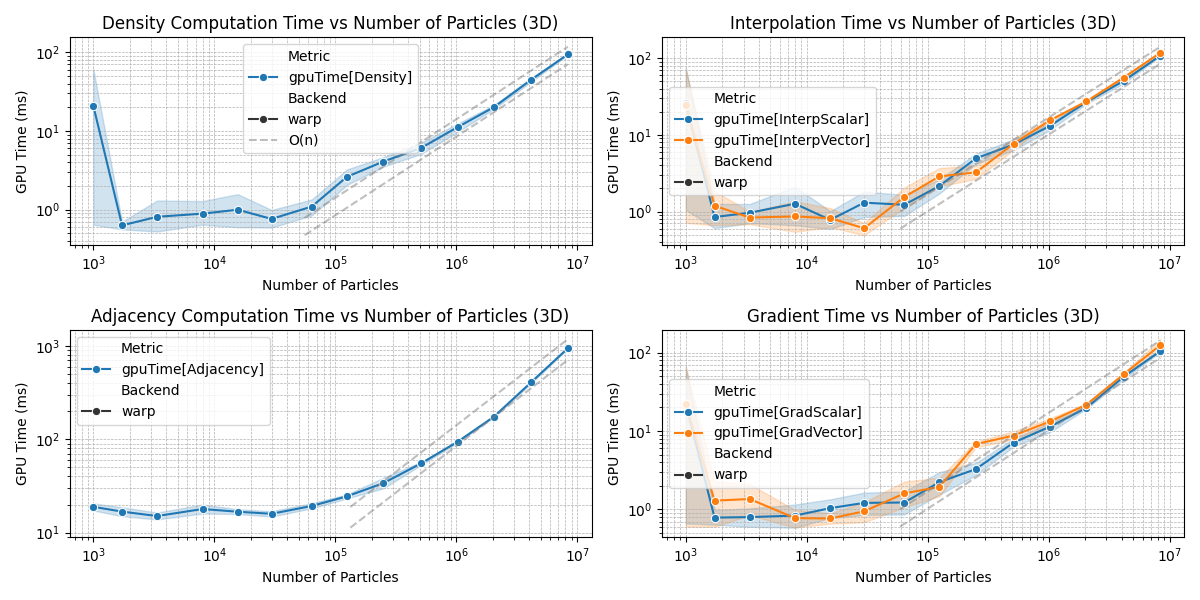

In [29]:
def add_scaling_line(ax, data, x_col, y_col, scale_factor=0.1, color='gray', linestyle='--', alpha=0.5):
    x_vals = data[x_col].unique()
    x_vals = np.sort(x_vals)
    y_mean = data.groupby(x_col)[y_col].mean()
    
    y_max = y_mean.max()
    y_min = y_mean.min()
    
    x_ref = x_vals[0]
    
    # print(f"x_vals: {x_vals}")
    # print(f"y_min: {y_min}, y_max: {y_max}")
    
    upper_scale = y_max * (1 + scale_factor)
    lower_scale = y_min * (1 + scale_factor)
    
    # now we want the line to go from [x, lower_scale] to [xmax, upper_scale] with a slope of 1 in log-log space, which means it should be a line of the form y = C * x, where C is a constant that we can determine based on the reference point (x_ref, y_ref)
    # print(f"upper_scale: {upper_scale}, lower_scale: {lower_scale}")
    y_ratio = upper_scale / lower_scale
    # print(f"y_ratio: {y_ratio}")
    x_lower = x_vals[-1] * (lower_scale / upper_scale)
    # print(f"x_lower: {x_lower}")
    ax.plot([x_lower, x_vals[-1]], [lower_scale, upper_scale], color=color, linestyle=linestyle, alpha=alpha, label='O(n)')
    
    upper_scale = y_max * (1 - scale_factor)
    lower_scale = y_min * (1 - scale_factor)
    y_ratio = upper_scale / lower_scale
    x_lower = x_vals[-1] * (lower_scale / upper_scale)
    ax.plot([x_lower, x_vals[-1]], [lower_scale, upper_scale], color=color, linestyle=linestyle, alpha=alpha)
    
scale_factor = 0.25    

fig, axis = plt.subplots(2,2, figsize = (12,6), squeeze = False)

curData =  stackedData[stackedData['Metric'] == 'gpuTime[Density]']

sns.lineplot(data = curData, x = 'Particles', y = 'Values', hue = 'Metric', style = 'Backend', ax = axis[0,0], marker = 'o')
axis[0,0].set_xscale('log')
axis[0,0].set_yscale('log')
axis[0,0].set_xlabel('Number of Particles')
axis[0,0].set_ylabel('GPU Time (ms)')
axis[0,0].set_title('Density Computation Time vs Number of Particles (3D)')
axis[0,0].grid(True, which = 'both', linestyle='--', linewidth=0.5)
add_scaling_line(axis[0, 0], curData, 'Particles', 'Values', scale_factor=scale_factor)
axis[0, 0].legend()

curData =  stackedData[stackedData['Metric'] == 'gpuTime[Adjacency]']
sns.lineplot(data = curData, x = 'Particles', y = 'Values', hue = 'Metric', style = 'Backend', ax = axis[1,0], marker = 'o')
axis[1,0].set_xscale('log')
axis[1,0].set_yscale('log')
axis[1,0].set_xlabel('Number of Particles')
axis[1,0].set_ylabel('GPU Time (ms)')
axis[1,0].set_title('Adjacency Computation Time vs Number of Particles (3D)')
axis[1,0].grid(True, which = 'both', linestyle='--', linewidth=0.5)
add_scaling_line(axis[1, 0], curData, 'Particles', 'Values', scale_factor=scale_factor)

curData = stackedData[np.logical_or(np.logical_or(stackedData['Metric'] == 'gpuTime[InterpScalar]', stackedData['Metric'] == 'gpuTime[InterpVector]'), stackedData['Metric'] == 'gpuTime[InterpMatrix]')]
sns.lineplot(data = curData, x = 'Particles', y = 'Values', hue = 'Metric', style = 'Backend', ax = axis[0,1], marker = 'o')
axis[0,1].set_xscale('log')
axis[0,1].set_yscale('log')
axis[0,1].set_xlabel('Number of Particles')
axis[0,1].set_ylabel('GPU Time (ms)')
axis[0,1].set_title('Interpolation Time vs Number of Particles (3D)')
axis[0,1].grid(True, which = 'both', linestyle='--', linewidth=0.5)
add_scaling_line(axis[0, 1], curData, 'Particles', 'Values', scale_factor=scale_factor)


curData = stackedData[np.logical_or(np.logical_or(stackedData['Metric'] == 'gpuTime[GradScalar]', stackedData['Metric'] == 'gpuTime[GradVector]'), stackedData['Metric'] == 'gpuTime[GradMatrix]')]
sns.lineplot(data = curData, x = 'Particles', y = 'Values', hue = 'Metric', style = 'Backend', ax = axis[1,1], marker = 'o')
axis[1,1].set_xscale('log')
axis[1,1].set_yscale('log')
axis[1,1].set_xlabel('Number of Particles')
axis[1,1].set_ylabel('GPU Time (ms)')
axis[1,1].set_title('Gradient Time vs Number of Particles (3D)')
axis[1,1].grid(True, which = 'both', linestyle='--', linewidth=0.5)
add_scaling_line(axis[1, 1], curData, 'Particles', 'Values', scale_factor=scale_factor)

fig.tight_layout()

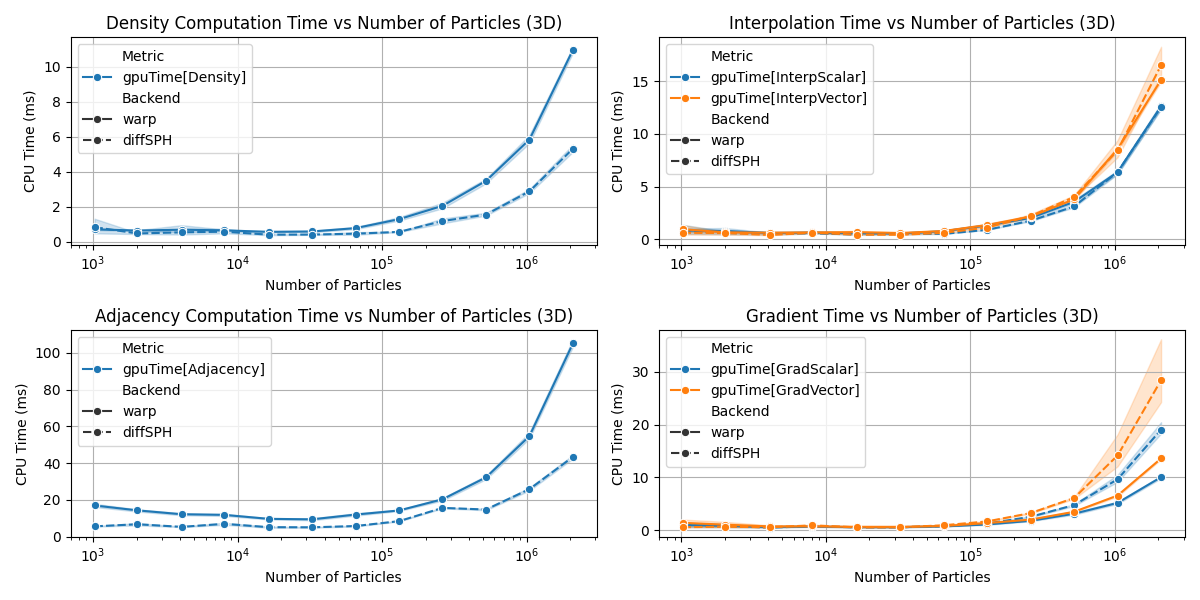

In [42]:
fig, axis = plt.subplots(2,2, figsize = (12,6), squeeze = False)

curData =  stackedData[stackedData['Metric'] == 'gpuTime[Density]']

sns.lineplot(data = curData, x = 'Particles', y = 'Values[cpu]', hue = 'Metric', style = 'Backend', ax = axis[0,0], marker = 'o')
axis[0,0].set_xscale('log')
# axis[0,0].set_yscale('log')
axis[0,0].set_xlabel('Number of Particles')
axis[0,0].set_ylabel('CPU Time (ms)')
axis[0,0].set_title('Density Computation Time vs Number of Particles (3D)')
axis[0,0].grid(True)

curData =  stackedData[stackedData['Metric'] == 'gpuTime[Adjacency]']
sns.lineplot(data = curData, x = 'Particles', y = 'Values[cpu]', hue = 'Metric', style = 'Backend', ax = axis[1,0], marker = 'o')
axis[1,0].set_xscale('log')
# axis[1,0].set_yscale('log')
axis[1,0].set_xlabel('Number of Particles')
axis[1,0].set_ylabel('CPU Time (ms)')
axis[1,0].set_title('Adjacency Computation Time vs Number of Particles (3D)')
axis[1,0].grid(True)

curData = stackedData[np.logical_or(np.logical_or(stackedData['Metric'] == 'gpuTime[InterpScalar]', stackedData['Metric'] == 'gpuTime[InterpVector]'), stackedData['Metric'] == 'gpuTime[InterpMatrix]')]
sns.lineplot(data = curData, x = 'Particles', y = 'Values[cpu]', hue = 'Metric', style = 'Backend', ax = axis[0,1], marker = 'o')
axis[0,1].set_xscale('log')
axis[0,1].set_xlabel('Number of Particles')
axis[0,1].set_ylabel('CPU Time (ms)')
axis[0,1].set_title('Interpolation Time vs Number of Particles (3D)')
axis[0,1].grid(True)

curData = stackedData[np.logical_or(np.logical_or(stackedData['Metric'] == 'gpuTime[GradScalar]', stackedData['Metric'] == 'gpuTime[GradVector]'), stackedData['Metric'] == 'gpuTime[GradMatrix]')]
sns.lineplot(data = curData, x = 'Particles', y = 'Values[cpu]', hue = 'Metric', style = 'Backend', ax = axis[1,1], marker = 'o')
axis[1,1].set_xscale('log')
axis[1,1].set_xlabel('Number of Particles')
axis[1,1].set_ylabel('CPU Time (ms)')
axis[1,1].set_title('Gradient Time vs Number of Particles (3D)')
axis[1,1].grid(True)

fig.tight_layout()

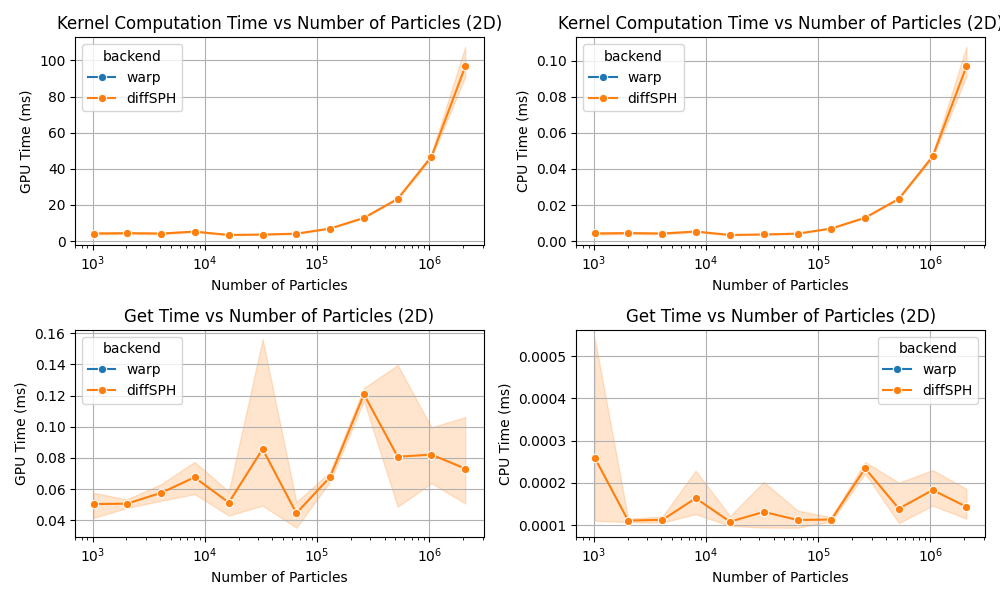

In [43]:
fig, axis = plt.subplots(2,2, figsize = (10,6), squeeze = False)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[Kernel]', hue = 'backend', ax = axis[0,0], marker = 'o')
axis[0,0].set_xscale('log')
axis[0,0].set_xlabel('Number of Particles')
axis[0,0].set_ylabel('GPU Time (ms)')
axis[0,0].set_title('Kernel Computation Time vs Number of Particles (2D)')
axis[0,0].grid(True)


sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'cpuTime[Kernel]', hue = 'backend', ax = axis[0,1], marker = 'o')
axis[0,1].set_xscale('log')
axis[0,1].set_xlabel('Number of Particles')
axis[0,1].set_ylabel('CPU Time (ms)')
axis[0,1].set_title('Kernel Computation Time vs Number of Particles (2D)')
axis[0,1].grid(True)


sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[Get]', hue = 'backend', ax = axis[1,0], marker = 'o')
axis[1,0].set_xscale('log')
axis[1,0].set_xlabel('Number of Particles')
axis[1,0].set_ylabel('GPU Time (ms)')
axis[1,0].set_title('Get Time vs Number of Particles (2D)')
axis[1,0].grid(True)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'cpuTime[Get]', hue = 'backend', ax = axis[1,1], marker = 'o')
axis[1,1].set_xscale('log')
axis[1,1].set_xlabel('Number of Particles')
axis[1,1].set_ylabel('CPU Time (ms)')
axis[1,1].set_title('Get Time vs Number of Particles (2D)')
axis[1,1].grid(True)

fig.tight_layout()

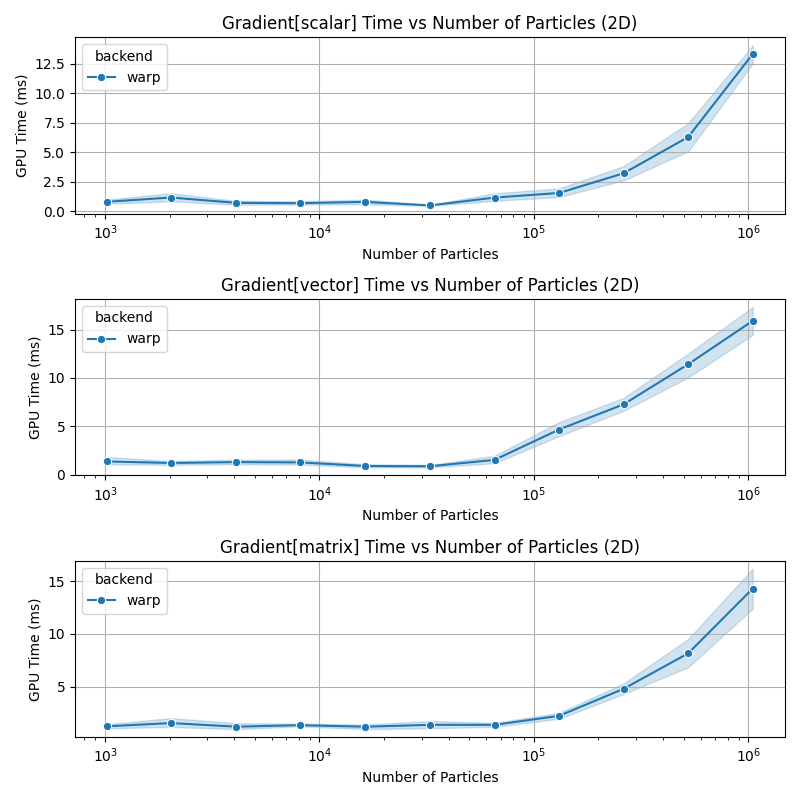

In [41]:
fig, axis = plt.subplots(3,1, figsize = (8,8), squeeze = False)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[GradScalar]', hue = 'backend', ax = axis[0,0], marker = 'o')
axis[0,0].set_xscale('log')
axis[0,0].set_xlabel('Number of Particles')
axis[0,0].set_ylabel('GPU Time (ms)')
axis[0,0].set_title('Gradient[scalar] Time vs Number of Particles (2D)')
axis[0,0].grid(True)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[GradVector]', hue = 'backend', ax = axis[1,0], marker = 'o')
axis[1,0].set_xscale('log')
axis[1,0].set_xlabel('Number of Particles')
axis[1,0].set_ylabel('GPU Time (ms)')
axis[1,0].set_title('Gradient[vector] Time vs Number of Particles (2D)')
axis[1,0].grid(True)

sns.lineplot(data = pdData[pdData['dim'] == 2], x = 'numParticles', y = 'gpuTime[GradMatrix]', hue = 'backend', ax = axis[2,0], marker = 'o')
axis[2,0].set_xscale('log')
axis[2,0].set_xlabel('Number of Particles')
axis[2,0].set_ylabel('GPU Time (ms)')
axis[2,0].set_title('Gradient[matrix] Time vs Number of Particles (2D)')
axis[2,0].grid(True)

fig.tight_layout()